# 04. Random Forest (Non-Linear Model)

As defined in Section B.2 of the proposal, we use Random Forest as a strong non-linear baseline.
Bagging-based ensembles are robust to noise and require little tuning compared to individual trees.

**Key Requirements (per proposal):**
- Evaluate Random Forest Regressor.
- Use 5-fold Cross-Validation.
- Compare against the linear baseline.


## 1. Setup

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('Outputs dir:', OUT_DIR.resolve())

Outputs dir: /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


## 2. Load Engineered Features

In [2]:
# Section IV.C: Load Development set and Local Test set separately
train_df      = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local_df = pd.read_parquet(OUT_DIR / 'test_local.parquet')
print('Loaded parquet files from', OUT_DIR.resolve())
print(f'Shapes: train_local {train_df.shape} | test_local {test_local_df.shape}')
train_df.head()


Loaded parquet files from /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs
Shapes: train_local (29008, 208) | test_local (7253, 208)


,id,blocked_days_Q1_2026,q3_days_total,q3_days_blocked,q3_days_avail,q3_blocking_rate,q3_avail_rate,q3_we_blocking_rate,q3_we_days,q3_wd_blocking_rate,q3_wd_days,q3_new_blockings,q3_new_unblockings,q3_we_minus_wd_blocking,q4_days_total,q4_days_blocked,q4_days_avail,q4_blocking_rate,q4_avail_rate,q4_we_blocking_rate,q4_we_days,q4_wd_blocking_rate,q4_wd_days,q4_new_blockings,q4_new_unblockings,q4_we_minus_wd_blocking,h2_days_total,h2_days_blocked,h2_days_avail,h2_blocking_rate,h2_avail_rate,h2_we_blocking_rate,h2_we_days,h2_wd_blocking_rate,h2_wd_days,h2_new_blockings,h2_new_unblockings,h2_we_minus_wd_blocking,m7_blocking_rate,m7_days,...,geo_cluster_1,geo_cluster_2,geo_cluster_3,geo_cluster_4,geo_cluster_5,geo_cluster_6,geo_cluster_7,geo_cluster_8,geo_cluster_9,geo_cluster_10,geo_cluster_11,geo_cluster_12,geo_cluster_13,geo_cluster_14,geo_cluster_15,geo_cluster_16,geo_cluster_17,geo_cluster_18,geo_cluster_19,rev_30d,rev_90d,rev_180d,rev_365d,rev_accel_90,q3_to_q4_blocking_trend,q3_to_q4_blocking_ratio,recent_fully_blocked,traj_slope,traj_recent3,traj_older3,traj_recent_older_ratio,traj_accel,traj_std,traj_nonzero_months,nb_mean_rate,nb_density,rate_vs_nb,geo_mean_rate,geo_density,rate_vs_geo
0,20256027,0,88.0,88.0,0.0,1.000000,0.000000,1.00,25.0,1.000000,63.0,0.0,0.0,0.000000,85,85,0,1.000000,0.000000,1.00,25,1.000000,60,0,0,0.000000,173,173,0,1.000000,0.000000,1.00,50,1.00000,123,0,0,0.00000,1.000000,30.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,1.000000,1,0.000000,1.000000,1.000000,0.952381,0.000000,0.000000,6,0.703702,395,0.296298,0.639355,4999,0.360645
1,13000527,0,88.0,88.0,0.0,1.000000,0.000000,1.00,24.0,1.000000,64.0,0.0,0.0,0.000000,86,86,0,1.000000,0.000000,1.00,25,1.000000,61,0,0,0.000000,174,174,0,1.000000,0.000000,1.00,49,1.00000,125,0,0,0.00000,1.000000,30.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.000000,1.000000,1,0.000000,1.000000,1.000000,0.952381,0.000000,0.000000,6,0.737892,39,0.262108,0.686704,1885,0.313296
2,1247932278114122984,0,89.0,59.0,30.0,0.662921,0.337079,0.68,25.0,0.656250,64.0,2.0,2.0,0.023750,86,86,0,1.000000,0.000000,1.00,25,1.000000,61,0,0,0.000000,175,145,30,0.828571,0.171429,0.84,50,0.82400,125,2,2,0.01600,0.033333,30.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.337079,1.508475,1,0.140952,1.000000,0.666667,1.395349,0.000000,0.357978,6,0.616666,2613,0.383334,0.603941,3146,0.396059
3,52339404,0,89.0,89.0,0.0,1.000000,0.000000,1.00,25.0,1.000000,64.0,0.0,0.0,0.000000,85,85,0,1.000000,0.000000,1.00,25,1.000000,60,0,0,0.000000,174,174,0,1.000000,0.000000,1.00,50,1.00000,124,0,0,0.00000,1.000000,30.0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,1.000000,1,0.000000,1.000000,1.000000,0.952381,0.000000,0.000000,6,0.788543,954,0.211457,0.757723,3342,0.242277
4,688995040218369146,71,89.0,81.0,8.0,0.910112,0.089888,0.88,25.0,0.921875,64.0,1.0,1.0,-0.041875,87,65,22,0.747126,0.252874,0.84,25,0.709677,62,2,2,0.130323,176,146,30,0.829545,0.170455,0.86,50,0.81746,126,3,3,0.04254,1.000000,30.0,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,2,2,0,-0.162986,0.820917,0,-0.058717,0.746825,0.908046,0.779530,-0.392857,0.176168,6,0.726239,298,-0.119096,0.663766,1440,-0.056623


In [3]:

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [4]:
TARGET   = 'blocked_days_Q1_2026'
ID_COL   = 'id'
DROP_COLS = [ID_COL, TARGET]

y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=DROP_COLS)
print('X shape:', X.shape, '| y mean:', y.mean().round(2))


X shape: (29008, 206) | y mean: 16.22


In [5]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# Cap very-high-cardinality categoricals by keeping only top-K most-frequent values
TOPK = 30
for c in cat_cols:
    top_values = X[c].value_counts(dropna=False).head(TOPK).index
    X[c] = X[c].where(X[c].isin(top_values), other='Other')

print(f'Numeric cols    : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}')


Numeric cols    : 205
Categorical cols: 1


## 3. Preprocessing `ColumnTransformer`
- **Numerics:** median imputation. Tree-based models don't need scaling.
- **Categoricals:** fill `NaN` with `'missing'`, then OneHotEncode (`handle_unknown='ignore'`).
- The whole thing lives in a Pipeline so that imputation is fit only on training folds (no leakage).

In [6]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('Preprocessor ready.')

Preprocessor ready.


## 4. 5-Fold CV Evaluation

Helper that runs one model through CV and returns OOF predictions + mean MSE.

In [7]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []

def evaluate_model(name, model, X, y, kf=kf):
    pipe = Pipeline(steps=[
        ('prep',  preprocessor),
        ('model', model),
    ])
    t0 = time.time()
    fold_mses = []
    fold_maes = []
    fold_r2s  = []
    oof = np.zeros(len(y))
    
    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[va])
        pred = np.clip(pred, 0, 90)   # target is bounded in [0, 90]
        oof[va] = pred
        
        mse = mean_squared_error(y[va], pred)
        mae = mean_absolute_error(y[va], pred)
        r2  = r2_score(y[va], pred)
        
        fold_mses.append(mse)
        fold_maes.append(mae)
        fold_r2s.append(r2)
        print(f'  fold {fold+1}: MSE = {mse:.3f} | MAE = {mae:.3f} | R2 = {r2:.3f}')
        
    elapsed = time.time() - t0
    mean_mse = float(np.mean(fold_mses))
    std_mse  = float(np.std(fold_mses))
    mean_mae = float(np.mean(fold_maes))
    mean_r2  = float(np.mean(fold_r2s))
    
    print(f'\n{name:>22s} | MSE = {mean_mse:7.3f} (±{std_mse:.3f}) | MAE = {mean_mae:7.3f} | R2 = {mean_r2:7.3f} | {elapsed:5.1f}s')
    np.save(OUT_DIR / f'oof_{name}.npy', oof)
    
    return {'name': name, 'mse_mean': mean_mse, 'mse_std': std_mse, 'mae_mean': mean_mae, 'r2_mean': mean_r2,
            'seconds': elapsed, 'oof': oof}

In [8]:
# Load Linear Regression baseline from disk (computed in notebook 03)
# This avoids recomputing the baseline in every notebook.
try:
    baseline_results = pd.read_csv(OUT_DIR / 'baseline_cv_results.csv')
    lr_row = baseline_results[baseline_results['name'] == 'LinearRegression'].iloc[0].to_dict()
    lr_row['oof'] = np.load(OUT_DIR / 'oof_LinearRegression.npy')
    results.append(lr_row)
    print(f"Loaded LinearRegression baseline: MSE = {lr_row['mse_mean']:.3f} (±{lr_row['mse_std']:.3f})")
except Exception as e:
    print(f"Could not load baseline from disk. Have you run notebook 03? Error: {e}")
    # Fallback to recomputing if not found
    # lr_model = LinearRegression()
    # results.append(evaluate_model('LinearRegression', lr_model, X, y))

Loaded LinearRegression baseline: MSE = 357.592 (±5.060)


### 4.1 RandomForestRegressor (Section IV.B.2)
The first non-linear baseline. RF is robust to outliers and requires minimal hyperparameter tuning.
As specified in Section IV.C, we use `RandomizedSearchCV` with a budget of 30-50 iterations.


In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'model__n_estimators': randint(100, 300), # Reduced max trees for speed
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': randint(2, 5),
    'model__max_features': ['sqrt', 'log2', None]
}

pipe_rf = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=15, # Section IV.C requirement
    cv=KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest Tuning (RandomizedSearchCV)...")
t0 = time.time()
search_rf.fit(X, y)
print(f"RF Tuning done in {(time.time()-t0)/60:.1f} min")
print("Best Parameters:", search_rf.best_params_)
print("Best CV MSE:", -search_rf.best_score_)

# Use the best model for the results
rf_model = search_rf.best_estimator_['model']
results.append(evaluate_model('RandomForest', rf_model, X, y))

Starting Random Forest Tuning (RandomizedSearchCV)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


RF Tuning done in 42.0 min
Best Parameters: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 152}
Best CV MSE: 302.7908920335035


  fold 1: MSE = 302.492 | MAE = 10.295 | R2 = 0.528


  fold 2: MSE = 298.913 | MAE = 10.360 | R2 = 0.528


  fold 3: MSE = 299.693 | MAE = 10.315 | R2 = 0.508


  fold 4: MSE = 304.454 | MAE = 10.343 | R2 = 0.521


  fold 5: MSE = 308.402 | MAE = 10.289 | R2 = 0.511

          RandomForest | MSE = 302.791 (±3.435) | MAE =  10.321 | R2 =   0.519 | 148.5s


## 5. Results Summary

In [10]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'oof'} for r in results])
results_df = results_df.sort_values('mse_mean').reset_index(drop=True)
results_df.to_csv(OUT_DIR / 'baseline_cv_results.csv', index=False)
print('CV results (sorted by MSE):')
results_df

CV results (sorted by MSE):


,name,mse_mean,mse_std,mae_mean,r2_mean,seconds
0,RandomForest,302.790892,3.434625,10.320595,0.519289,148.462404
1,LinearRegression,357.592072,5.059624,12.236696,0.432372,2.861503


In [11]:
# Simple mean-blend of the three OOFs — sanity check on whether averaging helps
oof_matrix = np.column_stack([r['oof'] for r in results])
oof_blend = np.clip(oof_matrix.mean(axis=1), 0, 90)
blend_mse = mean_squared_error(y, oof_blend)
print(f'Mean-of-models blend OOF MSE = {blend_mse:.3f}')

Mean-of-models blend OOF MSE = 314.535


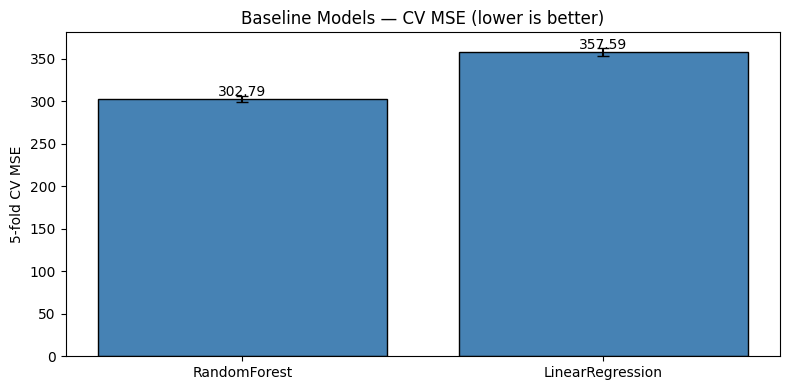

In [12]:
# Quick bar plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['name'], results_df['mse_mean'],
       yerr=results_df['mse_std'], capsize=4, color='steelblue', edgecolor='black')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('Baseline Models — CV MSE (lower is better)')
for i, v in enumerate(results_df['mse_mean']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_cv_bar.png', dpi=120); plt.show()

## 6. Refit Best Model on Full Train Set

In [13]:
best_name = results_df.iloc[0]['name']

models_dict = {}
if 'rf_model' in globals(): models_dict['RandomForest'] = rf_model
if 'lr_model' in globals(): models_dict['LinearRegression'] = lr_model

if best_name not in models_dict:
    if best_name == 'LinearRegression':
        from sklearn.linear_model import LinearRegression
        models_dict['LinearRegression'] = LinearRegression()
    else:
        backup_best = [n for n in results_df['name'] if n in models_dict][0]
        best_name = backup_best

best_model_obj = models_dict[best_name]
print(f'Best model: {best_name} (CV MSE = {results_df.iloc[0]["mse_mean"]:.3f})')

best_pipe = Pipeline(steps=[('prep', preprocessor), ('model', best_model_obj)])
best_pipe.fit(X, y)
print('Refit on full training set done.')


Best model: RandomForest (CV MSE = 302.791)


Refit on full training set done.


## 7. Section IV.C — Unbiased Local Test Evaluation & Feature Importance
We evaluate the best Random Forest on the 20% local test set reserved in notebook 02.
We also compute Permutation Importance to verify model drivers.

--- Unbiased Local Test Results (Random Forest) ---
Local Test MSE: 298.109
Local Test MAE: 10.077
Local Test R2 : 0.520

Saved local test predictions to ../outputs/test_local_pred_RandomForest.npy

Computing Permutation Importance on Local Test Set...


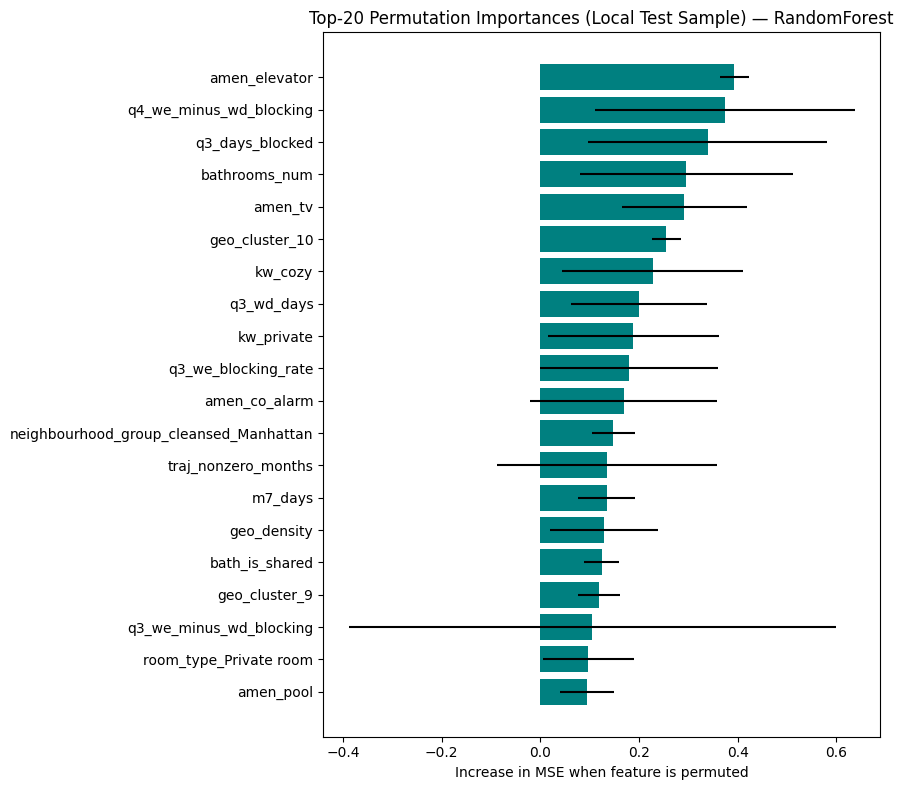

,feature,importance,std
136,amen_elevator,0.392719,0.029542
23,q4_we_minus_wd_blocking,0.373825,0.263454
1,q3_days_blocked,0.339130,0.242598
128,bathrooms_num,0.296222,0.215037
137,amen_tv,0.291999,0.127518
175,geo_cluster_10,0.255160,0.029230
146,kw_cozy,0.227522,0.182702
8,q3_wd_days,0.199719,0.138575
145,kw_private,0.188062,0.173252
5,q3_we_blocking_rate,0.179650,0.181420


In [14]:
# 1. Prepare Local Test Data
X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].astype(float).values

# Section IV.C: Align Categories for Local Test
# Crucial: test_local must use the same category mapping (top-K) as training.
for c in cat_cols:
    top_values = train_df[c].value_counts(dropna=False).head(TOPK).index
    X_test_local[c] = X_test_local[c].where(X_test_local[c].isin(top_values), other='Other')

# Align columns
X_test_local = X_test_local.reindex(columns=X.columns, fill_value=0)

# 2. Predict & Evaluate
# We use the best_pipe which was refit on the full development set (X, y) in the previous cell.
y_test_pred_rf = np.clip(best_pipe.predict(X_test_local), 0, 90)

test_mse_rf = mean_squared_error(y_test_local, y_test_pred_rf)
test_mae_rf = mean_absolute_error(y_test_local, y_test_pred_rf)
test_r2_rf  = r2_score(y_test_local, y_test_pred_rf)

print(f"--- Unbiased Local Test Results (Random Forest) ---")
print(f"Local Test MSE: {test_mse_rf:.3f}")
print(f"Local Test MAE: {test_mae_rf:.3f}")
print(f"Local Test R2 : {test_r2_rf:.3f}")

# 3. Save for Blender (Section 07)
np.save(OUT_DIR / 'test_local_pred_RandomForest.npy', y_test_pred_rf)
print(f"\nSaved local test predictions to {OUT_DIR / 'test_local_pred_RandomForest.npy'}")

# 4. Permutation Importance
print("\nComputing Permutation Importance on Local Test Set...")
# Optimization: Sample 1000 rows and use 3 repeats to speed up calculation drastically
X_sample = X_test_local.sample(n=min(1000, len(X_test_local)), random_state=RANDOM_STATE)
y_sample = y_test_local[X_sample.index] if isinstance(y_test_local, pd.Series) else y_test_local[X_sample.index]

perm = permutation_importance(best_pipe, X_sample, y_sample,
                              n_repeats=3, n_jobs=-1, random_state=RANDOM_STATE,
                              scoring='neg_mean_squared_error')

imp = pd.DataFrame({
    'feature': X.columns,
    'importance': -perm.importances_mean, # convert back to positive MSE gain
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

# Plot top 20
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='teal')
ax.set_title(f'Top-20 Permutation Importances (Local Test Sample) — {best_name}')
ax.set_xlabel('Increase in MSE when feature is permuted')
plt.tight_layout()
plt.show()

imp.head(10)